In [1]:
library('tidyverse')
library('ggpubr')
library('tictoc')
library('SelectSim')
library('ggrepel')

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: AlmaLinux 9.3 (Shamrock Pampas Cat)

Matrix products: default
BLAS/LAPACK: /mnt/ndata/arvind/envs/selectsim_R/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Zurich
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggrepel_0.9.6     SelectSim_0.0.1.5 tictoc_1.2.1      ggpubr_0.6.0     
 [5] lubridate_1.9.4   forcats_1.0.0     stringr_1.5.1     dplyr_1.1.4      
 [9] purrr_1.0.4       readr_2.1.5       tidyr_1.3.1       tibb

In [3]:
temp <- readRDS('/mnt/ndata/arvind/co_mutation_project_revision/oncogenic_syn_analysis/data/pan_can_mixture_gams_tcga_172.rds')

In [4]:
str(temp)

List of 4
 $ gam_mis_filtered: num [1:9082, 1:172] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  .. ..$ : chr [1:172] "AKT1" "ALK" "APC" "AR" ...
 $ gam_sil_filtered: num [1:9082, 1:172] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  .. ..$ : chr [1:172] "AKT1" "ALK" "APC" "AR" ...
 $ mixture_gams    :List of 7
  ..$ mix_90_10: num [1:9082, 1:172] 0 0 0 0 0 0 0 0 0 0 ...
  .. ..- attr(*, "dimnames")=List of 2
  .. .. ..$ : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  .. .. ..$ : chr [1:172] "AKT1" "ALK" "APC" "AR" ...
  ..$ mix_80_20: num [1:9082, 1:172] 0 0 0 0 0 0 0 0 0 0 ...
  .. ..- attr(*, "dimnames")=List of 2
  .. .. ..$ : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" 

In [5]:
str(temp$run_data)

List of 9
 $ mis_filtered:List of 3
  ..$ M               :List of 2
  .. ..$ M  :List of 1
  .. .. ..$ missense: num [1:172, 1:9082] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. ..$ : chr [1:172] "AKT1" "ALK" "APC" "AR" ...
  .. .. .. .. ..$ : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  .. ..$ tmb:List of 1
  .. .. ..$ missense:'data.frame':	9082 obs. of  2 variables:
  .. .. .. ..$ sample  : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  .. .. .. ..$ mutation: num [1:9082] 56 47 40 422 214 588 14 8 19 8 ...
  ..$ sample.class    : Named chr [1:9082] "GBM" "GBM" "LAML" "LAML" ...
  .. ..- attr(*, "names")= chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  ..$ alteration.class: Named chr [1:172] "MUT" "MUT" "MUT" "MUT" ...
  .. ..- attr(*, "names")= chr [1:172] "AKT1" "ALK" "APC" "AR" ...
 $ sil_filtered:List of 3
  ..

In [7]:
run_results<-c()
for(name in names(temp$run_data)){
    print(name)
    run_result<-selectX( M = temp$run_data[[name]]$M,
                                sample.class = temp$run_data[[name]]$sample.class,
                                alteration.class = temp$run_data[[name]]$alteration.class,
                                n.cores = 30,
                                min.freq = (0.001*9082),
                                n.permut = 1000,
                                lambda = 0.3,
                                tao = 1,
                                save.object = FALSE,
                                verbose = FALSE,
                                estimate_pairwise = FALSE,
                                maxFDR = 0.25)
    run_results[[name]]<-run_result$result  
    #saveRDS(run_result,paste0('../results/pan_can_tcga_',name,'_172_alteration_results.rds'))
    rm(run_result)
}

[1] "mis_filtered"
Total Time: 44.117 sec elapsed
[1] "sil_filtered"
Total Time: 97.868 sec elapsed
[1] "mix_90_10"
Total Time: 47.72 sec elapsed
[1] "mix_80_20"
Total Time: 42.72 sec elapsed
[1] "mix_70_30"
Total Time: 43.627 sec elapsed
[1] "mix_50_50"
Total Time: 40.813 sec elapsed
[1] "mix_30_70"
Total Time: 43.461 sec elapsed
[1] "mix_20_80"
Total Time: 42.509 sec elapsed
[1] "mix_10_90"
Total Time: 43.6 sec elapsed


In [8]:
str(run_results)

List of 9
 $ mis_filtered:'data.frame':	2346 obs. of  22 variables:
  ..$ SFE_1       : chr [1:2346] "PIK3CA" "BRAF" "BRAF" "BRAF" ...
  ..$ SFE_2       : chr [1:2346] "TP53" "NRAS" "TP53" "KRAS" ...
  ..$ name        : chr [1:2346] "PIK3CA - TP53" "BRAF - NRAS" "BRAF - TP53" "BRAF - KRAS" ...
  ..$ support_1   : num [1:2346] 1094 580 580 580 263 ...
  ..$ support_2   : num [1:2346] 1887 228 1887 680 1887 ...
  ..$ freq_1      : num [1:2346] 0.1205 0.0639 0.0639 0.0639 0.029 ...
  ..$ freq_2      : num [1:2346] 0.2078 0.0251 0.2078 0.0749 0.2078 ...
  ..$ overlap     : num [1:2346] 230 6 38 9 20 6 2 180 28 0 ...
  ..$ w_overlap   : num [1:2346] 205.82 3.88 25.06 7.4 19.08 ...
  ..$ max_overlap : num [1:2346] 574 176 120 104 145 83 40 468 92 45 ...
  ..$ freq_overlap: num [1:2346] 0.4007 0.0341 0.3167 0.0865 0.1379 ...
  ..$ r_overlap   : num [1:2346] 340.1 96.6 96 65.7 69.3 ...
  ..$ w_r_overlap : num [1:2346] 267.8 51.9 61.3 41.3 48.7 ...
  ..$ wES         : num [1:2346] -43.8 -33.9 -

In [ ]:
saveRDS(run_results,paste0('../results/pan_can_tcga_list_172_alteration_results.rds'))

In [9]:
run_results$mis_filtered %>% filter(FDR) %>% count(type)

type,n
<chr>,<int>
CO,12
ME,60


In [10]:
run_results$mis_filtered %>% filter(FDR) %>% dim()
run_results$mix_90_10 %>% filter(FDR) %>% dim()
run_results$mix_80_20 %>% filter(FDR) %>% dim()
run_results$mix_70_30 %>% filter(FDR) %>% dim()
run_results$mix_50_50 %>% filter(FDR) %>% dim()
run_results$mix_30_70 %>% filter(FDR) %>% dim()
run_results$mix_20_80 %>% filter(FDR) %>% dim()
run_results$mix_10_90 %>% filter(FDR) %>% dim()

[1] 72 22

[1] 61 22

[1] 45 22

[1] 46 22

[1] 26 22

[1] 13 22

[1]  2 22

[1]  0 22

In [ ]:
saveRDS(temp,file='../data/pan_can_mixture_gams_tcga_172_alteration.rds')

# Generating the plot

In [ ]:
pan_can_results_list <- readRDS('../results/pan_can_tcga_list_172_results.rds')

In [2]:
str(pan_can_results_list,max.level = 1)

List of 9
 $ mis_filtered:'data.frame':	2346 obs. of  22 variables:
 $ sil_filtered:'data.frame':	14706 obs. of  22 variables:
 $ mix_90_10   :'data.frame':	2346 obs. of  22 variables:
 $ mix_80_20   :'data.frame':	2346 obs. of  22 variables:
 $ mix_70_30   :'data.frame':	2346 obs. of  22 variables:
 $ mix_50_50   :'data.frame':	2346 obs. of  22 variables:
 $ mix_30_70   :'data.frame':	2346 obs. of  22 variables:
 $ mix_20_80   :'data.frame':	2346 obs. of  22 variables:
 $ mix_10_90   :'data.frame':	2346 obs. of  22 variables:


In [4]:
(0.01*9082)

[1] 90.82

In [104]:
results_df<-c()
for ( name in names(pan_can_results_list)){
    if(name =='sil_filtered') next
    else{
        result <- pan_can_results_list[[name]]
        result$log_overlap <- log10(result$w_overlap + 1)
        result$log_r_overlap <- log10(result$w_r_overlap + 1)
        result <- result %>% mutate(cat = case_when((FDR == TRUE & type=='ME') ~ 'Mutually Exclusive' ,
                                                                            (FDR == TRUE & type=='CO') ~ 'Co-occurent', 
                                                                            FDR == FALSE ~ "Not Significant"))
        results_df[[name]]<-result    
    }
}

In [105]:
names(results_df)

[1] "mis_filtered" "mix_90_10"    "mix_80_20"    "mix_70_30"    "mix_50_50"   
[6] "mix_30_70"    "mix_20_80"    "mix_10_90"

In [106]:
length(names(results_df))

[1] 8

In [107]:
plot_lists<-c()
i=1
for(name in names(results_df)){
   options(repr.plot.width=5, repr.plot.height=5)    
   plot_lists[[i]]<- ggscatter(results_df[[i]],
                  x = "log_r_overlap",
                  y = "log_overlap", 
                  color = "cat",
                  fill="cat",
                  palette =c("Co-occurent" = "forestgreen", "Mutually Exclusive" = "purple", "Not Significant" = "grey60"), 
                  repel = TRUE,
                  alpha = 1) + 
        annotate("text",
               x = 1.5,
               y = 0,
               label = paste("Pairs:",nrow(results_df[[i]]%>%filter(FDR))),
               size = 6, 
               hjust = 0) +
        xlab("Expected weighted overlap (log10)") + 
        ylab("Observed weighted overlap (log10)") + geom_abline(slope = 1, intercept = 0,linetype=2)+
        ggtitle(paste0('TCGA Pan-Cancer\n 172 Genes \n',name)) + theme_pubr() +
        theme(legend.position = "top", 
             legend.title = element_blank(),
             plot.title = element_text(hjust = 0.5), 
             text = element_text(size = 14))+ 
        scale_x_continuous(limits = c(0, 3), breaks = c(0, 0.5, 1, 1.5,2,2.5,3))+
        scale_y_continuous(limits = c(0, 3), breaks = c(0, 0.5, 1, 1.5,2,2.5,3))
    i=i+1
}


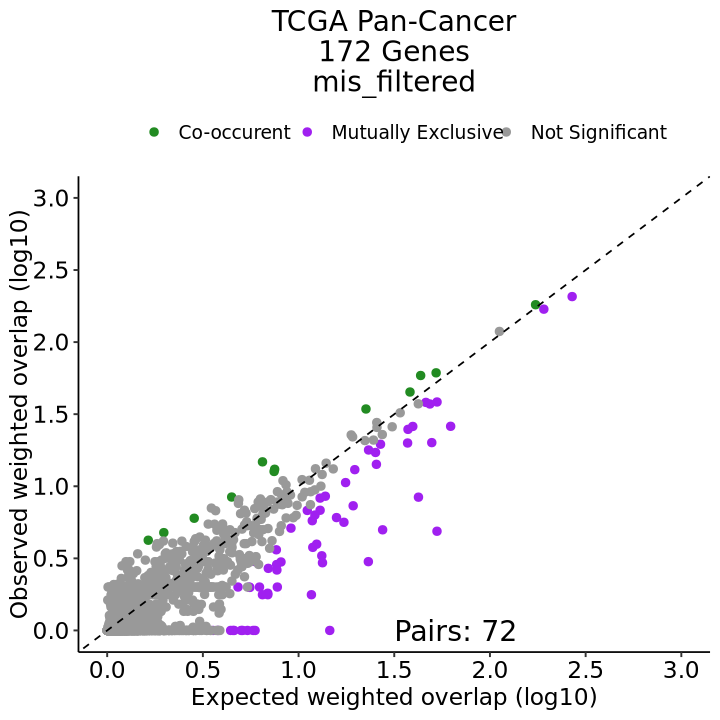

In [108]:
options(repr.plot.width = 6, repr.plot.height = 6)
plot_lists[[1]]

In [110]:
p_all <- ggarrange(plotlist = plot_lists,nrow=3,ncol=3)

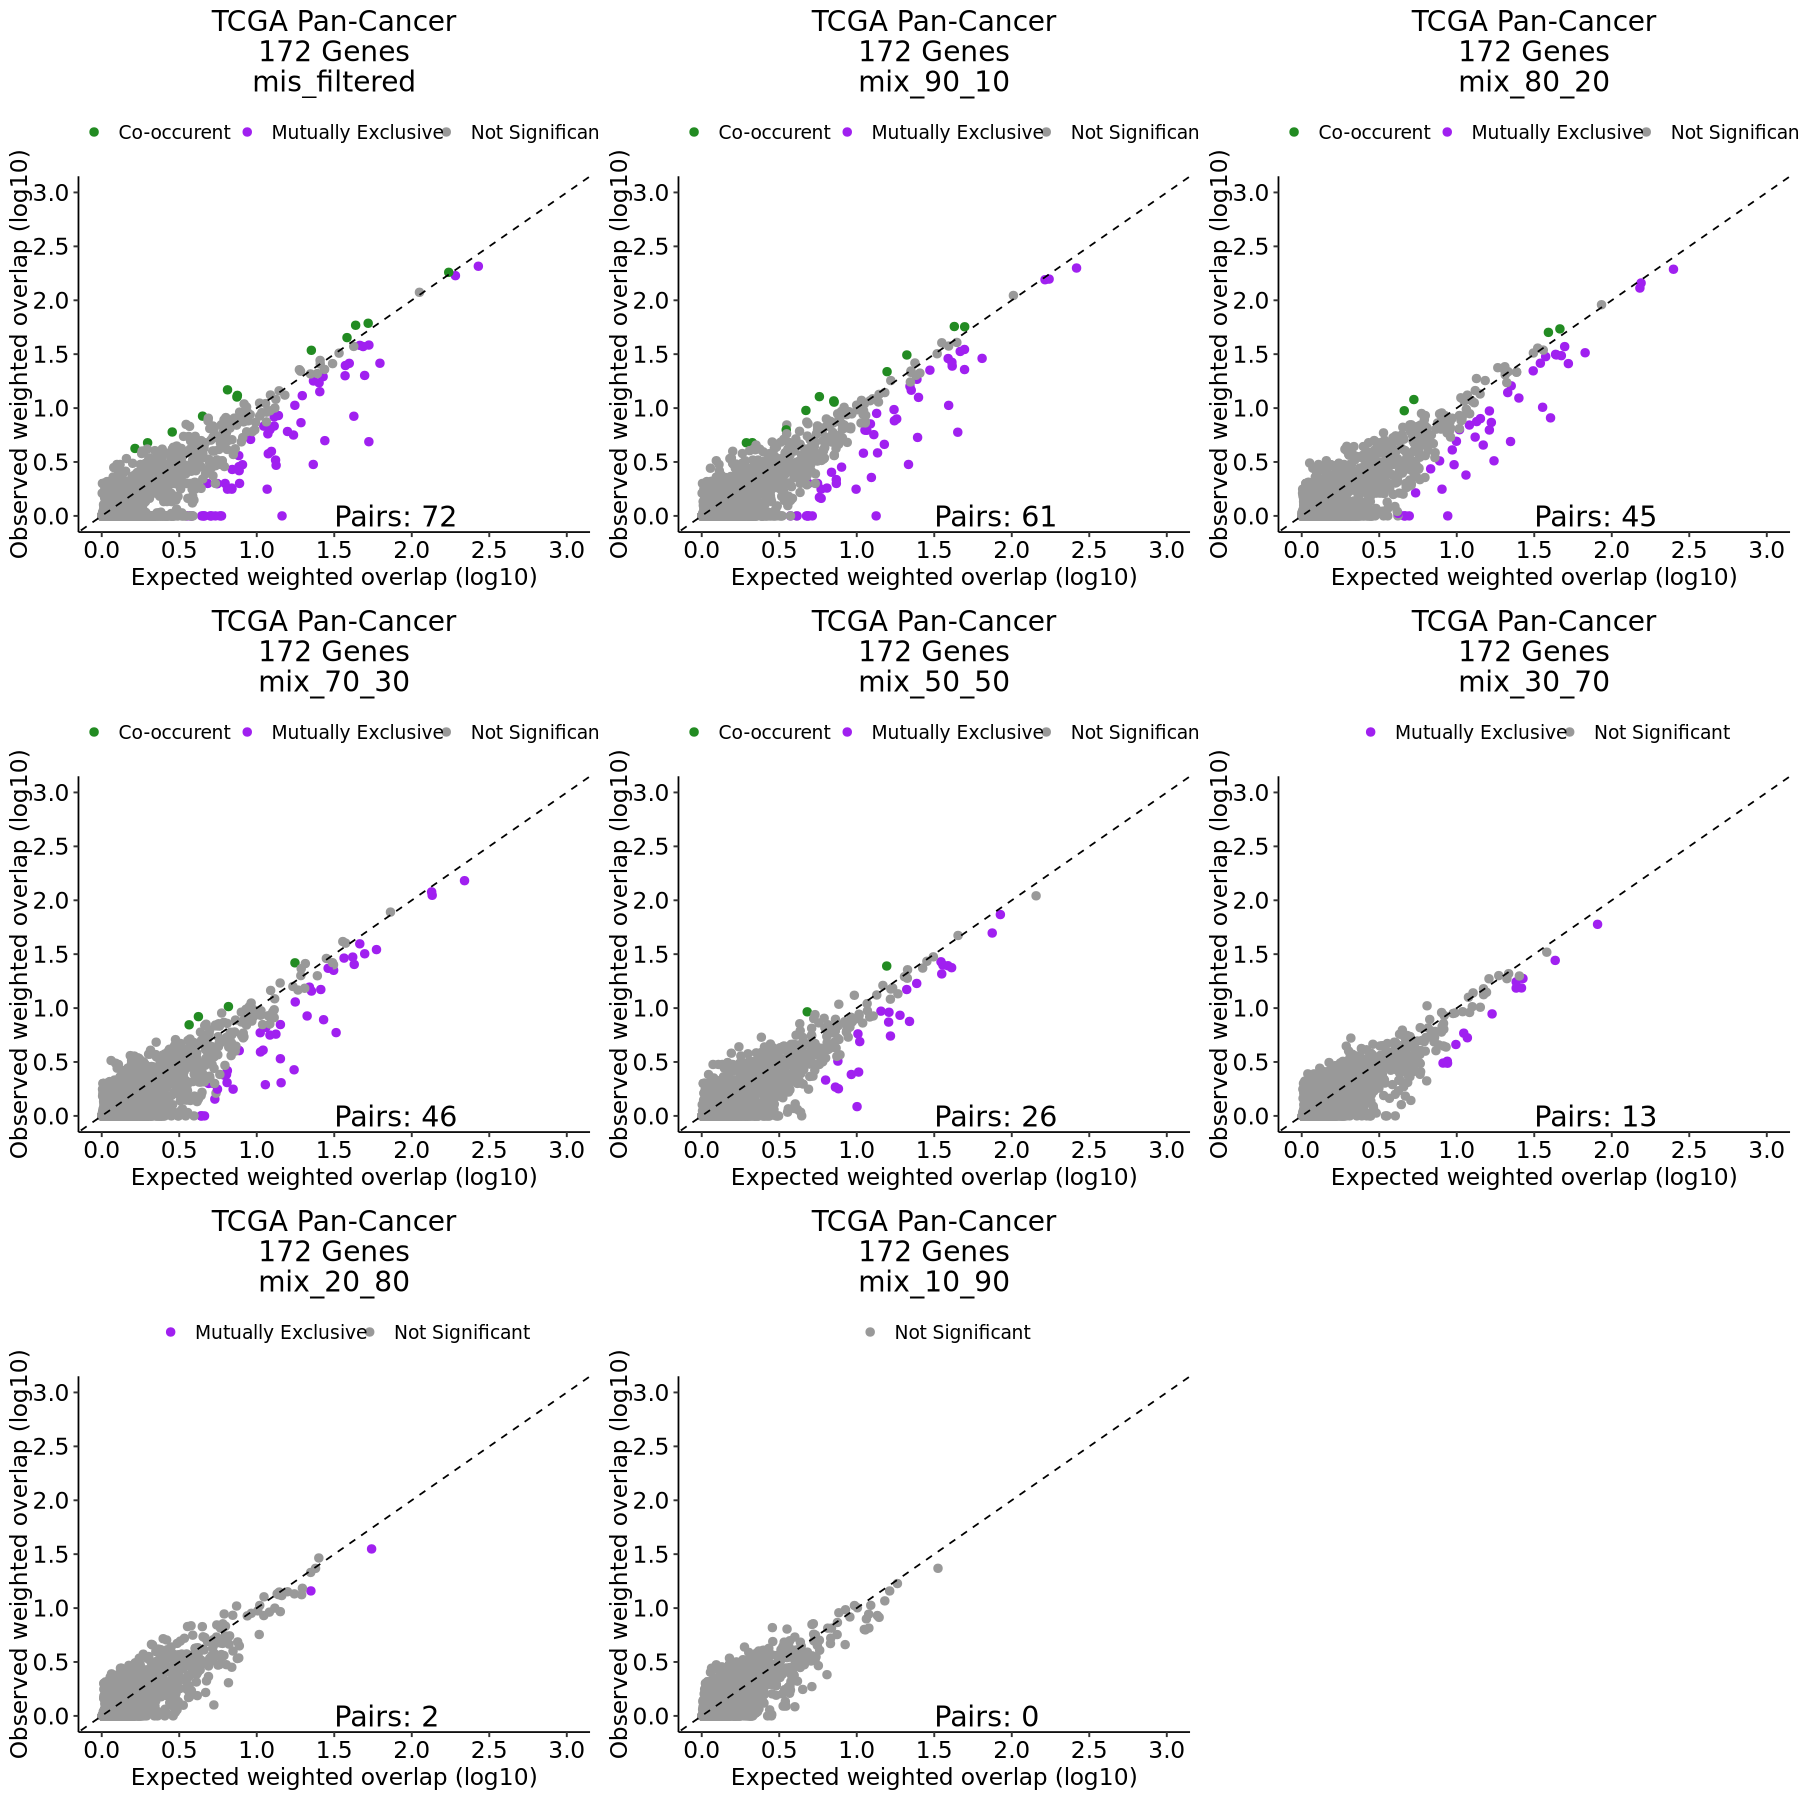

In [111]:
options(repr.plot.width=15, repr.plot.height=15)
p_all